# Assignment 1 2AMM10 2025-2026

## Group: The Big Batch Theory
### Member 1: Haneul Choi (<insert_student_nr>)
### Member 2: Dimitar Dimitrov (<insert_student_nr>)
### Member 3: Wouter Feijen (1491032)

## Task 1 

Additional Imports

In [1]:
from torchvision import transforms
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data.sampler import BatchSampler
from torch.utils.data import DataLoader

from itertools import combinations
from tqdm.auto import tqdm

from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm
import platform
import numpy as np

# use cuda if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 1.1 Dataset and Visualization

In [2]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else: 
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

Defining Transformation and Datasets

In [3]:
# Calculate the mean and std using the training dataset
training_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_dataset = AppleDataset(subset="train", transform=training_transforms)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=False)

def calculate_mean_std(loader):

    mean = 0.0
    std = 0.0
    count_images = 0

    for images, _ in loader:
        image_count_in_batch = images.size(0)
        images = images.view(image_count_in_batch, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        count_images += image_count_in_batch

    mean /= count_images
    std /= count_images   

    return mean, std

mean, std = calculate_mean_std(train_loader)
print(f"Mean: {mean}, Std: {std}")

Mean: tensor([0.6123, 0.5190, 0.4066]), Std: tensor([0.2739, 0.3120, 0.3521])


In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.6123, 0.5190, 0.4066), std=(0.2739, 0.3120, 0.3521))
])# ... # your code here

train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

# your code here
# Number of samples in each dataset
print(f"Number of samples in train_data: {len(train_data)}")
print(f"Number of samples in test_data: {len(test_data)}")
print(f"Number of samples in support_new_data: {len(support_new_data)}")
print(f"Number of samples in test_new_data: {len(test_new_data)}")

# Classes in each dataset
print()
print(f"Classes in train_data: {set(train_data.targets)}")
print(f"Classes in test_data: {set(test_data.targets)}")
print(f"Classes in support_new_data: {set(support_new_data.targets)}")
print(f"Classes in test_new_data: {set(test_new_data.targets)}")

Number of samples in train_data: 3068
Number of samples in test_data: 1538
Number of samples in support_new_data: 1570
Number of samples in test_new_data: 781

Classes in train_data: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}
Classes in test_data: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}
Classes in support_new_data: {20, 21, 22, 23, 24, 25, 26, 27, 28, 29}
Classes in test_new_data: {20, 21, 22, 23, 24, 25, 26, 27, 28, 29}


#### 1.2 - Loss Function

Helper Function

In [5]:
def pdist(vectors):
    distance_matrix = -2 * vectors.mm(torch.t(vectors)) + vectors.pow(2).sum(dim=1).view(1, -1) + vectors.pow(2).sum(
        dim=1).view(-1, 1)
    return distance_matrix

BalancedBatchSampler

In [6]:
class BalancedBatchSampler(BatchSampler):
    """Guarantees the composition of every single batch consists of a specific number of classes (n_classes)
    and a specific number of instances per class (n_samples), and that it contains valid positive pairs together
    with a variety of negative options."""
    
    def __init__(self, labels, n_classes, n_samples):
        self.labels = labels
        self.labels_set = list(set(self.labels))
        self.label_to_indices = {label: np.where(np.array(self.labels) == label)[0]
                                 for label in self.labels_set}
        for label in self.labels_set:
            np.random.shuffle(self.label_to_indices[label])
        self.used_label_indices_count = {label: 0 for label in self.labels_set}
        self.count = 0

        self.n_classes = n_classes
        self.n_samples = n_samples
        self.n_dataset = len(self.labels)
        self.batch_size = self.n_classes * self.n_samples

    def __iter__(self):
        self.count = 0
        while self.count + self.batch_size < self.n_dataset:
            classes = np.random.choice(self.labels_set, self.n_classes, replace=False)
            indices = []
            for class_ in classes:
                indices.extend(self.label_to_indices[class_]
                               [self.used_label_indices_count[class_]:self.used_label_indices_count[class_]
                                 + self.n_samples])
                self.used_label_indices_count[class_] += self.n_samples
                if self.used_label_indices_count[class_] + self.n_samples > len(self.label_to_indices[class_]):
                    np.random.shuffle(self.label_to_indices[class_])
                    self.used_label_indices_count[class_] = 0
            yield indices
            self.count += self.batch_size

    def __len__(self):
        return self.n_dataset // self.batch_size

Informative and Random Triplet Selector Classes

In [7]:
# Informative Triplet Selector
class InformativeTripletSelector():
    def __init__(self, margin):
        super(InformativeTripletSelector, self).__init__()
        self.margin = margin

    def informative_negative(self, loss_values):

        informative_negative = np.where(loss_values > 0)[0]
        return np.random.choice(informative_negative) if len(informative_negative) > 0 else None
    
    def get_triplets(self, embeddings, labels):

        if torch.cuda.is_available():
            embeddings = embeddings.detach().cpu()
            labels = labels.detach().cpu().numpy()

        distance_matrix = pdist(embeddings)
        distance_matrix = distance_matrix.cpu()

        triplets = []

        for label in set(labels):
            label_mask = (labels == label)
            label_indices = np.where(label_mask)[0]
            if len(label_indices) < 2:
                continue
            negative_indices = np.where(~label_mask)[0]
            anchor_positives = list(combinations(label_indices, 2))
            anchor_positives = np.array(anchor_positives)

            ap_distances = distance_matrix[anchor_positives[:, 0], anchor_positives[:, 1]]
            for anchor_positive, ap_distance in zip(anchor_positives, ap_distances):
                loss_values = ap_distance - distance_matrix[anchor_positive[0], negative_indices] + self.margin
                loss_values = loss_values.data.cpu().numpy()

                informative_negative = self.informative_negative(loss_values)
                if informative_negative is not None:
                    informative_negative = negative_indices[informative_negative]
                    triplets.append([anchor_positive[0], anchor_positive[1], informative_negative])
        
        if len(triplets) == 0:
            triplets.append([anchor_positive[0], anchor_positive[1], negative_indices[0]])

        return torch.LongTensor(np.array(triplets))
    
# Validation Triplet Selector (Random Triplet Selector)
class RandomTripletSelector():
    def __init__(self):
        super(RandomTripletSelector, self).__init__()

    def get_triplets(self, embeddings, labels):
        labels = labels.detach().cpu().numpy()
        triplets = []

        for label in set(labels):
            label_mask = (labels == label)
            label_indices = np.where(label_mask)[0]
            if len(label_indices) < 2:
                continue
            negative_indices = np.where(~label_mask)[0]
            anchor_positives = list(combinations(label_indices, 2))

            temp_triplets = [[anchor_positive[0], anchor_positive[1], np.random.choice(negative_indices)] for anchor_positive in anchor_positives]
            triplets += temp_triplets

        return torch.LongTensor(np.array(triplets))

Triplet Loss Class

In [8]:
# Triplet loss function
class TripletLoss(nn.Module):
    def __init__(self, margin, triplet_selector):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.triplet_selector = triplet_selector

    def forward(self, embeddings, labels):

        triplets = self.triplet_selector.get_triplets(embeddings, labels)

        if embeddings.is_cuda:
            triplets = triplets.cuda()

        anchor_idx = triplets[:, 0]
        positive_idx = triplets[:, 1]
        negative_idx = triplets[:, 2]

        ap_distances = (embeddings[anchor_idx] - embeddings[positive_idx]).pow(2).sum(1)  # .pow(.5)
        an_distances = (embeddings[anchor_idx] - embeddings[negative_idx]).pow(2).sum(1)  # .pow(.5)
        losses = F.relu(ap_distances - an_distances + self.margin)

        return losses.mean()

#### 1.3 - Model Implementation & Training Procedure

EmbeddingNet Class

In [9]:
class Lambda(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, x):
        return self.func(x)

class EmbeddingNet(nn.Module):
    
    def __init__(self, embedding_dim=128):
        super(EmbeddingNet, self).__init__()

        # Feature Extractor
        self.front_layer = nn.Sequential(
            # Conv Layer 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 3
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Adaptive Average Pooling (flatten spatial dimensions)
            nn.AdaptiveAvgPool2d((1, 1)),

            Lambda(lambda x: x.view(x.size(0), -1)),

            # Fully Connected Layer
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True)
        )

        # final linear projection down to the target embedding_dim
        self.last_layer = nn.Linear(1024, embedding_dim)

    def forward(self, x):
        x = self.front_layer(x)
        x = self.last_layer(x)

        # processes the output to have a euclidean norm of 1
        x = F.normalize(x, p=2, dim=1)
        return x

    def get_embedding(self, x):
        return self.forward(x)

Trainer Class

In [10]:
def plot_loss_history(train_losses, validation_losses):
    n_epochs = len(train_losses)
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss')
    if validation_losses:
        plt.plot(range(1, n_epochs + 1), validation_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Train{" and Validation " if validation_losses else ""} Loss per Epoch')
    plt.legend()
    plt.show()

def get_base_path():
    if platform.node() == "WFcachyOS":
        return r"/home/wouterf/Documents/DS&AI Courses/DL/assignment-1"
    elif platform.node() == "-999":
        return r"C:\Users\wfeij\Documents\Local Course Files\Deep Learning\DL Assignment 1"
    else:
        return ""

# Training loop
class Trainer():
    def __init__(self,
                 model: nn.Module,
                 device: torch.device,
                 criterion: nn.Module,
                 optimizer: torch.optim.Optimizer,
                 train_DataLoader: torch.utils.data.DataLoader,
                 validation_DataLoader: torch.utils.data.DataLoader,
                 n_epochs: int,
                 criterion_validation: nn.Module = None
                 ):
        
        self.model = model
        self.device = device
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_DataLoader = train_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.n_epochs = n_epochs

        if criterion_validation is None:
            self.criterion_validation = criterion
        else:
            self.criterion_validation = criterion_validation

    def run_trainer(self):
        train_losses_per_epoch = []
        validation_losses_per_epoch = []

        for epoch in range(self.n_epochs):

            self.model.train()

            train_losses = []

            train_bar = tqdm(
            enumerate(self.train_DataLoader),
            total=len(self.train_DataLoader),
            desc=f"Training epoch {epoch + 1}/{self.n_epochs}",
            leave=True,
            dynamic_ncols=True
            )
            
            for batch_idx, batch in train_bar:

                x, y = batch
                input, target = x.to(self.device), y.to(self.device)
                self.optimizer.zero_grad()
                output = self.model(input)
                loss = self.criterion(output, target)

                loss_value = loss.item()
                train_losses.append(loss_value)

                train_bar.set_postfix({
                    "batch": f"{batch_idx + 1}/{len(self.train_DataLoader)}",
                    "loss": f"{loss_value:.4f}",
                    "avg_loss": f"{np.mean(train_losses):.4f}"
                })

                loss.backward()
                self.optimizer.step()

            self.model.eval()
            validation_losses = []

            validation_bar = tqdm(
                enumerate(self.validation_DataLoader),
                total=len(self.validation_DataLoader),
                desc=f"Validation epoch {epoch + 1}/{self.n_epochs}",
                leave=True,
                dynamic_ncols=True
            )

            for batch_idx, batch in validation_bar:

                x, y = batch
                input, target = x.to(self.device), y.to(self.device)
                
                with torch.no_grad():
                    output = self.model(input)
                    loss = self.criterion_validation(output, target)

                    loss_value = loss.item()
                    validation_losses.append(loss_value)

                    validation_bar.set_postfix({
                    "batch": f"{batch_idx + 1}/{len(self.validation_DataLoader)}",
                    "loss": f"{loss_value:.4f}",
                    "avg_loss": f"{np.mean(validation_losses):.4f}"
                    })
            
            train_losses_per_epoch.append(np.mean(train_losses))
            validation_losses_per_epoch.append(np.mean(validation_losses))

            # Print epoch, train loss and validation loss
            print(f"Epoch: {epoch + 1}/{self.n_epochs}, Train Loss: {np.mean(train_losses):.4f}, Validation Loss: {np.mean(validation_losses):.4f}")

        # plot train and validation losses per epoch
        plot_loss_history(train_losses_per_epoch, validation_losses_per_epoch)

        return train_losses_per_epoch,validation_losses_per_epoch

Training the Model

Using device: cuda
Found existing model weights. Loading...
Model loaded successfully!


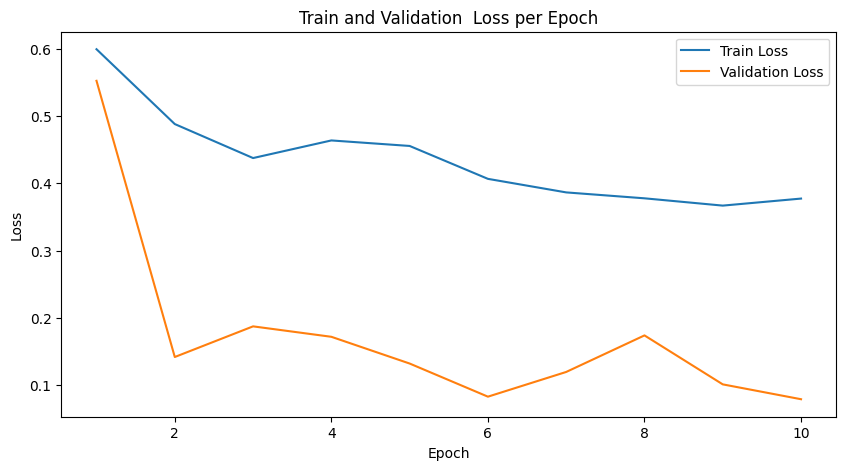

In [11]:
print(f"Using device: {device}")

# init model and save path
embedding_net = EmbeddingNet(embedding_dim=128).to(device)
        
base_path = get_base_path()
model_save_path = os.path.join(base_path,"embedding_net_weights.pth")

# margin
margin = 1

# criterion
triplet_selector = InformativeTripletSelector(margin=margin)
criterion = TripletLoss(margin=margin, triplet_selector=triplet_selector)

validation_selector = RandomTripletSelector()
criterion_validation = TripletLoss(margin=margin, triplet_selector=validation_selector)

# optimizer
optimizer = torch.optim.Adam(embedding_net.parameters(), lr=1e-3, weight_decay=1e-5)

# batch sampler and dataloader
train_batch_sampler = BalancedBatchSampler(train_data.targets, n_classes=10, n_samples=20)
validation_batch_sampler = BalancedBatchSampler(test_data.targets, n_classes=10, n_samples=20)
train_loader = torch.utils.data.DataLoader(train_data, batch_sampler=train_batch_sampler)
validation_loader = torch.utils.data.DataLoader(test_data, batch_sampler=validation_batch_sampler)

if os.path.exists(model_save_path):
    print("Found existing model weights. Loading...")
    # load dictionary
    checkpoint = torch.load(model_save_path, map_location=device, weights_only=False)

    # load weights and set model to eval mode
    embedding_net.load_state_dict(checkpoint["model_state_dict"])
    embedding_net.eval()
    print("Model loaded successfully!")

    plot_loss_history(checkpoint['train_losses'], checkpoint['validation_losses'])
else:
    print("No saved weights found. Starting training...")

    # training
    train = Trainer(model=embedding_net,
                    device=device,
                    criterion=criterion,
                    optimizer=optimizer,
                    train_DataLoader=train_loader,
                    validation_DataLoader=validation_loader,
                    n_epochs=10,
                    criterion_validation=criterion_validation)

    train_losses,val_losses = train.run_trainer()

    # create checkpoint
    checkpoint = {
        'model_state_dict': embedding_net.state_dict(),
        'train_losses': train_losses,
        'validation_losses': val_losses
    }

    # save model weights
    torch.save(checkpoint,model_save_path)
    print(f"Training Complete. Model saved to {model_save_path}")

Sanity Check: t-SNE Plot<br>
Identical apples should be grouped together while different ones should be apart.

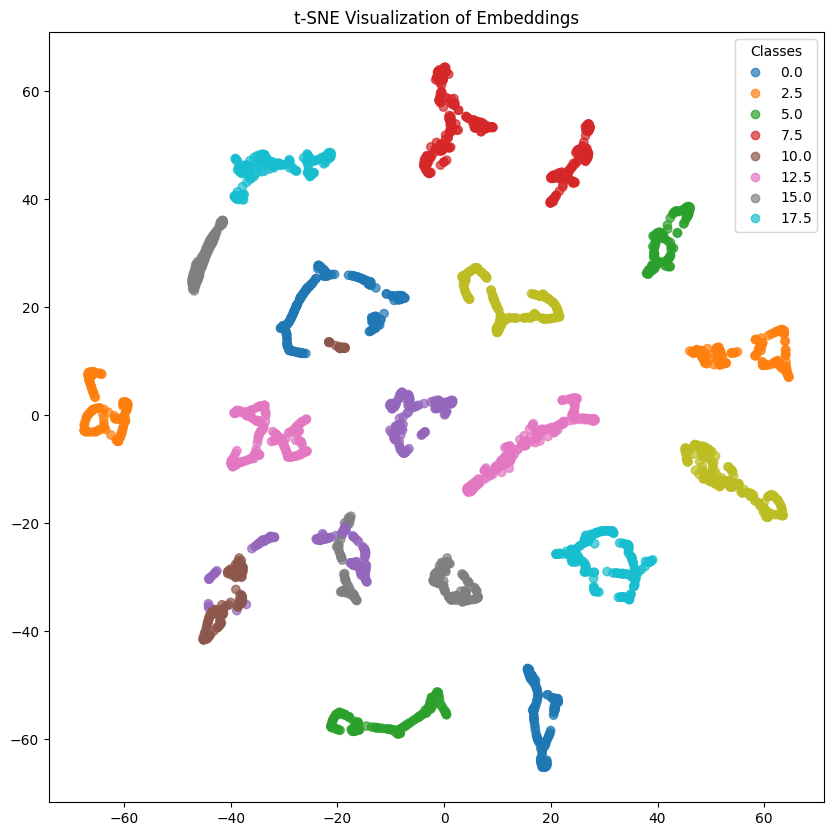

In [12]:
def plot_tsne_embeddings(embeddings, labels, xlim=None, ylim=None):
    tsne = TSNE(n_components=2)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 10))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='tab10', alpha=0.7)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title("t-SNE Visualization of Embeddings")
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.show()

# get embeddings of train data and visualize
embedding_net.eval()
train_embeddings = []
train_labels = []
with torch.no_grad():
    for x, y in train_loader:
        x = x.to(device)
        embeddings = embedding_net.get_embedding(x)
        train_embeddings.append(embeddings.cpu())
        train_labels.append(y)
train_embeddings = torch.cat(train_embeddings).numpy()
train_labels = torch.cat(train_labels).numpy()

plot_tsne_embeddings(train_embeddings, train_labels)

#### 1.4 & 1.5 - Classification of seen apples at (un)seen angles

In [13]:
def extract_embeddings(dataset, model, batch_size=128):
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    embeddings_list = []
    labels_list = []

    model.eval()

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting embeddings"):
            images = images.to(device, non_blocking=True)

            embeddings = model.get_embedding(images)

            embeddings_list.append(embeddings.cpu().numpy())
            labels_list.append(labels.numpy())

    embeddings = np.concatenate(embeddings_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)

    return embeddings, labels

# k-nearest neighbors
def retrieval_classification_accuracy(reference_embeddings, reference_labels,
                                      query_embeddings, query_labels,
                                      k=1):
    # compute Euclidean distances betweeen every query embedding and every reference embedding
    distances = cdist(query_embeddings, reference_embeddings)

    predictions = []

    # for each query, sort the distances to fnd the k=5 closest training embeddings
    for query_idx in range(len(query_embeddings)):
        sorted_idx = np.argsort(distances[query_idx])
        top_k_idx = sorted_idx[:k]
        top_k_labels = reference_labels[top_k_idx]

        # look at k=5 closest training images and assign the most frequent label to the query image
        values, counts = np.unique(top_k_labels, return_counts=True)
        predicted_label = values[np.argmax(counts)]

        predictions.append(predicted_label)

    predictions = np.array(predictions)
    accuracy = np.mean(predictions == query_labels)

    return accuracy, predictions

# ======= 1.4) Evaluation on seen apples =======
# Extract embeddings from train and test datasets
train_embeddings, train_labels = extract_embeddings(train_data, embedding_net)
test_embeddings, test_labels = extract_embeddings(test_data, embedding_net)

# Evaluate retrieval-based classification accuracy (seen data)
accuracy, predictions = retrieval_classification_accuracy(train_embeddings, train_labels, test_embeddings, test_labels, k=5)
print(f"Retrieval-based classification accuracy on seen data (k=5): {accuracy:.4f}")

# ======= 1.5) Evaluation on unseen apples =======
# Extract embeddings from support_new_data and test_new_data
support_new_embeddings, support_new_labels = extract_embeddings(support_new_data, embedding_net)
test_new_embeddings, test_new_labels = extract_embeddings(test_new_data, embedding_net)

# Evaluate retrieval-based classification accuracy (unseen data)
accuracy_new, predictions_new = retrieval_classification_accuracy(support_new_embeddings, support_new_labels,test_new_embeddings, test_new_labels, k=5)

print(f"Retrieval-based classification accuracy on unseen data (k=5): {accuracy_new:.4f}")

Extracting embeddings:   0%|          | 0/24 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/13 [00:00<?, ?it/s]

Retrieval-based classification accuracy on seen data (k=5): 0.9480


Extracting embeddings:   0%|          | 0/13 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Retrieval-based classification accuracy on unseen data (k=5): 0.9001


## Task 2

In [14]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0]) 

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

##### Defining Transformation and new Datasets

In [15]:
# Recalculate mean/std for GardenDataset 
training_transforms_g = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_dataset_g = GardenDataset(subset="train", transform=training_transforms_g)

train_loader_g = torch.utils.data.DataLoader(train_dataset_g, batch_size=64, shuffle=False)

garden_mean, garden_std = calculate_mean_std(train_loader_g)
print(f"GardenDataset  mean={garden_mean}  std={garden_std}")

GardenDataset  mean=tensor([0.5192, 0.4353, 0.3843])  std=tensor([0.3052, 0.3423, 0.3681])


In [16]:
transform_garden = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5192, 0.4353, 0.3843), std=(0.3052, 0.3423, 0.3681)),
])

# reload with the correct normalisation
train_data        = GardenDataset(subset="train", transform=transform_garden)

# scenario 1
test_data         = GardenDataset(subset="test",  transform=transform_garden)

# scenario 2 
train_data_family = GardenDataset(subset="train", transform=transform_garden, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform_garden, class_level="family")

# scenario 3
support_all_data  = GardenDataset(subset="train", transform=transform_garden, item_subset="all")
test_new_data     = GardenDataset(subset="test",  transform=transform_garden, item_subset="new")

# scenario 4
support_all_data_family = GardenDataset(subset="train", transform=transform_garden,
                                        family_subset="all", class_level="family")
test_new_data_family    = GardenDataset(subset="test",  transform=transform_garden,
                                        family_subset="new", class_level="family")

# Number of samples in each dataset
print("Number of samples in:")
print(f" - Number of samples in train_data: {len(train_data)}")
# scenario 1
print(f" - Number of samples in test_data: {len(test_data)}")
# scenario 2
print(f" - Number of samples in support_all_data: {len(support_all_data)}")
print(f" - Number of samples in test_data_family: {len(test_data_family)}")
# scenario 3
print(f" - Number of samples in train_data_family: {len(train_data_family)}")
print(f" - Number of samples in test_new_data: {len(test_new_data)}")
# scenario 4
print(f" - Number of samples in support_all_data_family: {len(support_all_data_family)}")
print(f" - Number of samples in test_new_data_family: {len(test_new_data_family)}")

# Classes in each dataset
print("\nClasses in each dataset:")
print(f" - train_data: {set(train_data.targets)}")
print(f" - test_data: {set(test_data.targets)}")
print(f" - train_data_family: {set(train_data_family.targets)}")
print(f" - test_data_family: {set(test_data_family.targets)}")
print(f" - support_all_data: {set(support_all_data.targets)}")
print(f" - test_new_data: {sorted(set(test_new_data.targets))}")
print(f" - support_all_data_family: {set(support_all_data_family.targets)}")
print(f" - test_new_data_family: {set(test_new_data_family.targets)}")

Number of samples in:
 - Number of samples in train_data: 27678
 - Number of samples in test_data: 13843
 - Number of samples in support_all_data: 31622
 - Number of samples in test_data_family: 13843
 - Number of samples in train_data_family: 27678
 - Number of samples in test_new_data: 1971
 - Number of samples in support_all_data_family: 31909
 - Number of samples in test_new_data_family: 2119

Classes in each dataset:
 - train_data: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 27, 28, 33, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 49, 50, 51, 52, 55, 56, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 76, 77, 79, 80, 82, 83, 84, 85, 86, 87, 89, 90, 91, 92, 93}
 - test_data: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 27, 28, 33, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 49, 50, 51, 52, 55, 56, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 76, 77, 79, 80, 82, 83, 84, 85, 86, 87, 89, 90, 91, 9

##### Train Model on GardenDataset

Using device: cuda
Found existing model weights. Loading...
Model loaded successfully!


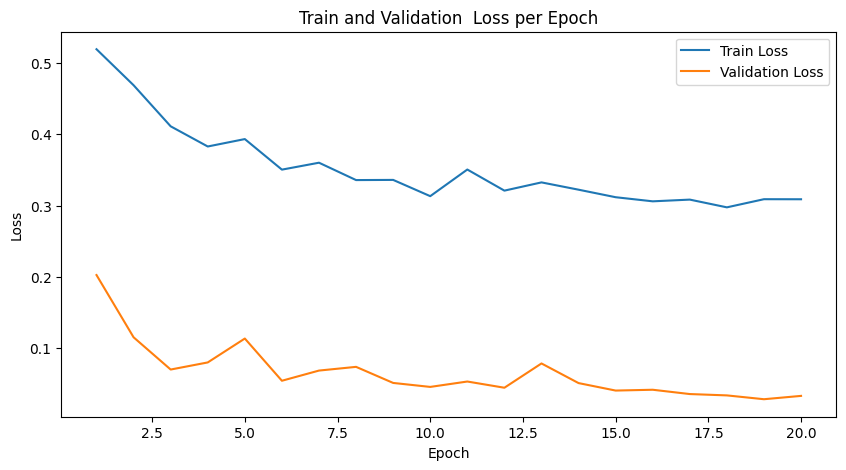

In [17]:
# model w same architecture, same hyperparams; We reuse EmbeddingNet, BalancedBatchSampler, TripletLoss
# and Trainer from Task 1. Only the dataset and sampler parameters change
print(f"Using device: {device}")

train_sampler_g = BalancedBatchSampler(train_data.targets, n_classes=10, n_samples=20)
val_sampler_g   = BalancedBatchSampler(test_data.targets,  n_classes=10, n_samples=20)
train_loader_g = torch.utils.data.DataLoader(
    train_data,
    batch_sampler=train_sampler_g,
    num_workers=4 if platform.node()=="WFcachyOS" else 0,
    pin_memory=True
)
val_loader_g = torch.utils.data.DataLoader(
    test_data,
    batch_sampler=val_sampler_g,
    num_workers=4 if platform.node()=="WFcachyOS" else 0,
    pin_memory=True
)

margin_g = 1

triplet_selector_g   = InformativeTripletSelector(margin=margin_g)
criterion_g          = TripletLoss(margin=margin_g, triplet_selector=triplet_selector_g)
criterion_g_val      = TripletLoss(margin=margin_g, triplet_selector=RandomTripletSelector())

garden_model = EmbeddingNet(embedding_dim=128).to(device)
optimizer_g          = torch.optim.Adam(garden_model.parameters(), lr=1e-3, weight_decay=1e-5)

base_path = get_base_path()
model_save_path_t2 = os.path.join(base_path,"garden_model.pth")

if os.path.exists(model_save_path_t2):
    print("Found existing model weights. Loading...")
    # load dictionary
    checkpoint_t2 = torch.load(model_save_path_t2, map_location=device, weights_only=False)

    # load weights and set model to eval mode
    garden_model.load_state_dict(checkpoint_t2["model_state_dict"])
    garden_model.eval()
    print("Model loaded successfully!")

    plot_loss_history(checkpoint_t2['train_losses'], checkpoint_t2['validation_losses'])

else:
    print("No saved weights found. Starting training...")
    # train model
    trainer_g = Trainer(
        model=garden_model, device=device,
        criterion=criterion_g, optimizer=optimizer_g,
        train_DataLoader=train_loader_g,
        validation_DataLoader=val_loader_g,
        n_epochs=20,
        criterion_validation=criterion_g_val,
    )

    train_losses,val_losses = trainer_g.run_trainer() #5min40.4sec

    # create checkpoint
    checkpoint = {
        'model_state_dict': garden_model.state_dict(),
        'train_losses': train_losses,
        'validation_losses': val_losses
    }
    torch.save(checkpoint, model_save_path_t2)

Extracting Embeddings for all Scenarios

In [18]:
# mapping item to family predictions
item_idx_to_family_idx = {}
for fam_lbl, item_lbl in zip(train_data.targets_family, train_data.targets_item):
    item_idx_to_family_idx[item_lbl] = fam_lbl

def item_preds_to_family_preds(item_preds):
    return np.array([item_idx_to_family_idx[p] for p in item_preds])

# extract embeddings scenario 1 and 2 (seen items)
# note: Scenario 2 reuses these embeddings to save compute time as underlying images are identical
train_embs, train_item_lbls = extract_embeddings(train_data, garden_model)
test_embs, test_item_lbls =extract_embeddings(test_data, garden_model)

# we need family labels for 2 and 4
train_family_lbls = np.array(train_data.targets_family)
test_family_lbls = np.array(test_data.targets_family)

# scenario 3 (unseen items)
support_all_embs, support_all_item_lbls = extract_embeddings(support_all_data, garden_model)
test_new_embs, test_new_item_lbls = extract_embeddings(test_new_data, garden_model)

# scenario 4 (unseen families)
support_all_family_lbls = np.array(support_all_data.targets_family)
test_new_family_lbls_arr = np.array(test_new_data_family.targets)

Extracting embeddings:   0%|          | 0/217 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/109 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/248 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating Performance for all Scenarios

In [19]:
# ── Scenario 1: seen items, item-level accuracy ───────────────────────────────
acc1, preds1 = retrieval_classification_accuracy(
    train_embs, train_item_lbls, test_embs, test_item_lbls, k=5)
print(f"Scenario 1 - Item accuracy (seen): {acc1:.4f}")


# ── Scenario 2: seen items, family-level accuracy ────────────────────────────
# Use the item-level k-NN but compare against family labels in the support set
acc2, preds2_item = retrieval_classification_accuracy(
    train_embs, train_item_lbls,
    test_embs, test_item_lbls,
    k=5
)
preds2_family = item_preds_to_family_preds(preds2_item)
acc2_fam = np.mean(preds2_family == test_family_lbls)
print(f"Scenario 2 - Family accuracy (seen): {acc2_fam:.4f}")


# ── Scenario 3: unseen items, item-level accuracy ────────────────────────────
acc3, preds3 = retrieval_classification_accuracy(
    support_all_embs, support_all_item_lbls, test_new_embs, test_new_item_lbls, k=5)
print(f"Scenario 3 - Item accuracy (new items): {acc3:.4f}")


# ── Scenario 4: unseen families, family-level accuracy ───────────────────────
support_all_fam_embs, support_all_fam_lbls = extract_embeddings(support_all_data_family, garden_model)
test_new_fam_embs,    test_new_fam_lbls    = extract_embeddings(test_new_data_family,    garden_model)

acc4, preds4 = retrieval_classification_accuracy(
    support_all_fam_embs, support_all_fam_lbls, test_new_fam_embs, test_new_fam_lbls, k=5)
print(f"Scenario 4 - Family accuracy (new families): {acc4:.4f}")

Scenario 1 - Item accuracy (seen):0.9956
Scenario 2 - Family accuracy (seen): 0.9997
Scenario 3 - Item accuracy (new items): 0.9919


Extracting embeddings:   0%|          | 0/250 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/17 [00:00<?, ?it/s]

Scenario 4 - Family accuracy (new families): 0.9986


#### 2.1 How does the Item Classification Accuracy Vary Across Families in Scenario 1

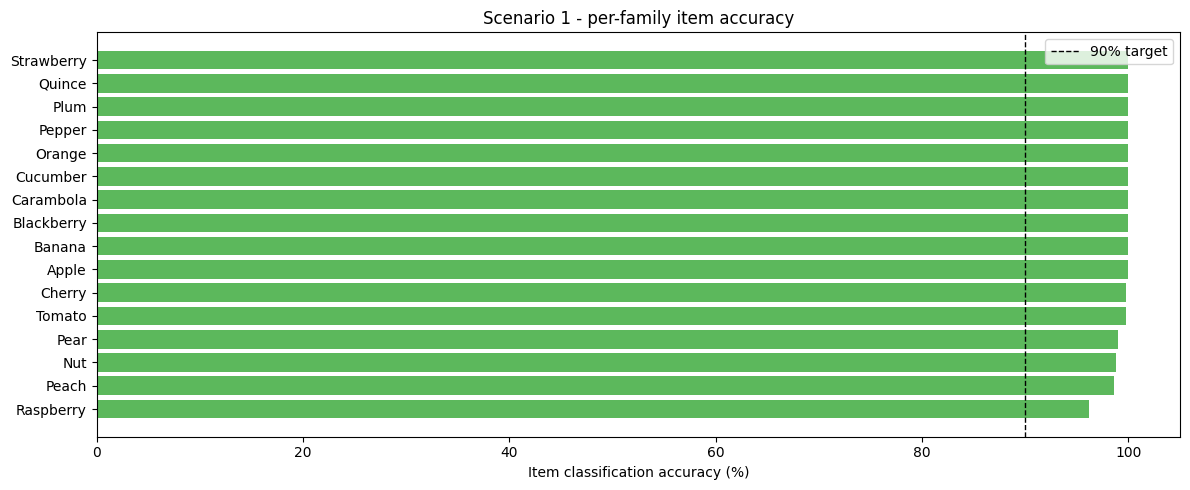

Most challenging product families:
Raspberry: 96.2%
Peach: 98.6%
Nut: 98.8%


In [20]:
# scenario 1 visualization
true_family_labels = np.array(test_data.targets_family)
true_item_labels   = np.array(test_data.targets_item)

# map idx to labels
family_name_lookup = {
    idx: name for name, idx in train_data.family_to_idx.items()}

item_name_lookup = {
    idx: name for name, idx in train_data.item_to_idx.items()}

# calculate accuracy for each family
family_accuracy = {}
for fam_idx in sorted(set(true_family_labels)):
    family_mask = true_family_labels == fam_idx
    correct_preds = np.sum(preds1[family_mask] == true_item_labels[family_mask])
    accuracy = correct_preds / family_mask.sum()
    family_name = family_name_lookup[fam_idx]
    family_accuracy[family_name] = accuracy

sorted_families = sorted(family_accuracy, key=family_accuracy.get)
sorted_accuracies = [family_accuracy[f] for f in sorted_families]
colors          = ["#d9534f" if acc < 0.9 else "#5cb85c" for acc in sorted_accuracies]

plt.figure(figsize=(12, 5))
plt.barh(sorted_families, [acc * 100 for acc in sorted_accuracies], color=colors)
plt.axvline(90, color="black", linestyle="--", linewidth=1, label="90% target")
plt.xlabel("Item classification accuracy (%)")
plt.title("Scenario 1 - per-family item accuracy")
plt.legend()
plt.tight_layout()
plt.show()

print("Most challenging product families:")
for family in sorted_families[:3]:
    print(f"{family}: {family_accuracy[family] * 100:.1f}%")

#### 2.2 Confusion Matrix to Assess which Families are Most Likely to be Confused by Our Model in Scenario 2

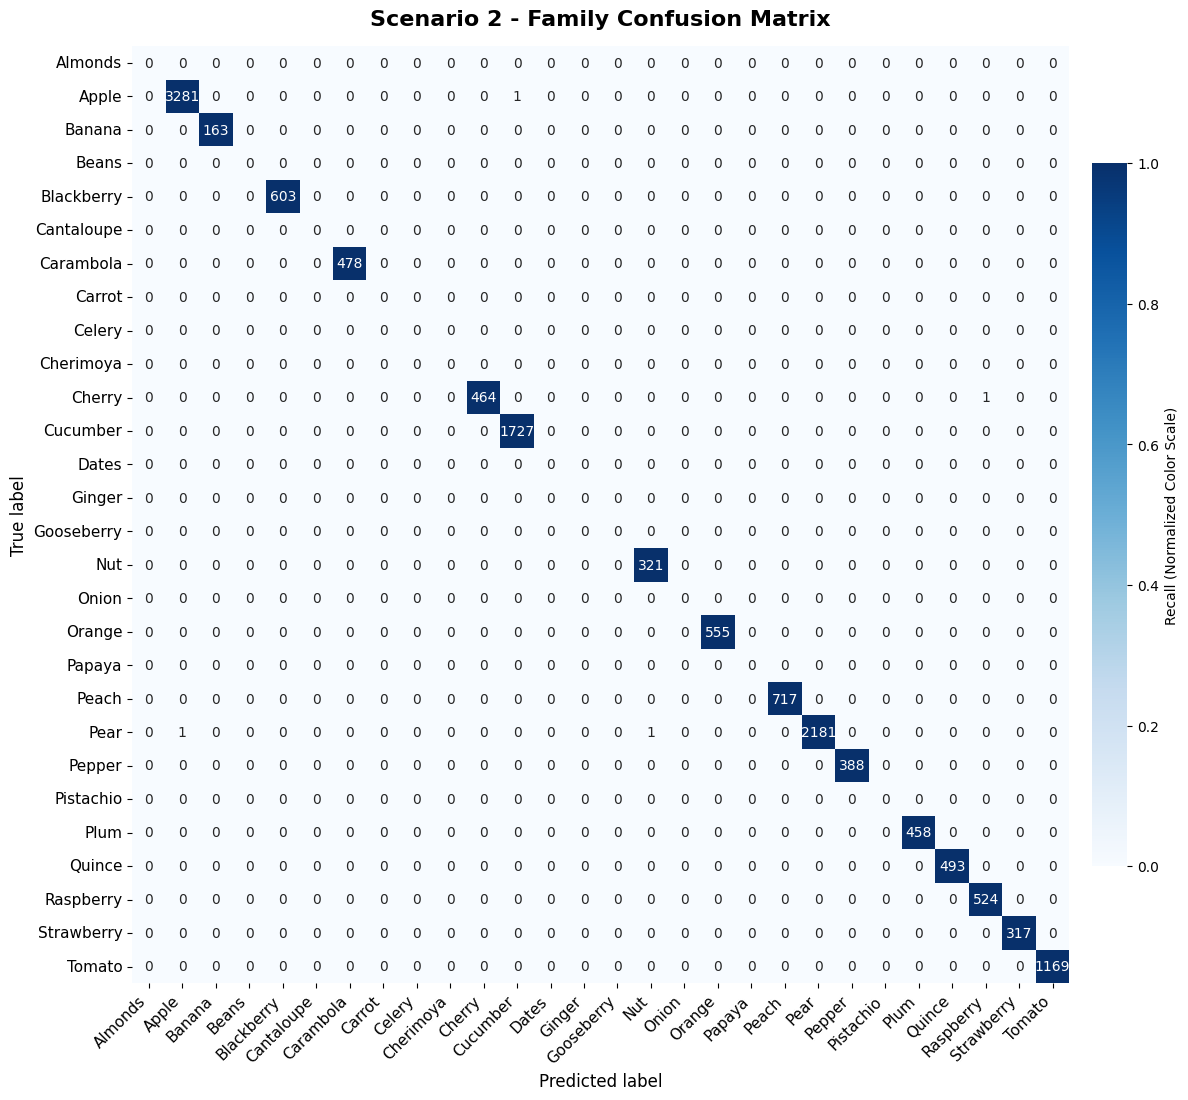

In [21]:
# scenario 2 visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

# get ordered class names
ordered_family_names = [
    family_name_lookup[idx]
    for idx in sorted(family_name_lookup)
]

# generate 2 matrices using sklearn to improve visualization coloring 
cm_raw = confusion_matrix(
    test_family_lbls, preds2_family, 
    labels=sorted(family_name_lookup)
)
cm_norm = confusion_matrix(
    test_family_lbls, preds2_family, 
    labels=sorted(family_name_lookup), 
    normalize='true' # normalizes by row (Recall)
)

# init figure
fig, ax = plt.subplots(figsize=(13, 11))

# create seaborn heatmap
sns.heatmap(cm_norm, annot=cm_raw, fmt="d", cmap="Blues",
            xticklabels=ordered_family_names, yticklabels=ordered_family_names,
            square=True,
            annot_kws={"size": 10},
            cbar_kws={'shrink': 0.75, 'pad': 0.02, 'label': 'Recall (Normalized Color Scale)'})

# format text and axes
plt.title("Scenario 2 - Family Confusion Matrix", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)

# rotate x-labels and align to ticks
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

## Task 3

Initialize Original Datasets

In [22]:
# init train and test datasets
train_data_both = GardenDataset(
    class_level="both",transform=transform_garden,
    subset="train",family_subset="main",item_subset="main"
)
test_data_both = GardenDataset(
    class_level="both",transform=transform_garden,
    subset="test",family_subset="main",item_subset="main"
)

Setup Dataset Wrapper and Adapted TripletLoss

In [23]:
class JointDatasetWrapper(Dataset):
    """Wraps the 3-item dataset to return (image, target_tensor) to make these datasets compatible
    with the Trainer class from Task 1."""
    def __init__(self, original_dataset):
        self.dataset = original_dataset
        # add targets_item so BalancedBatchSampler can read it
        self.targets_item = original_dataset.targets_item 
        
    def __len__(self):
        return len(self.dataset)
        
    def __getitem__(self, idx):
        image, family_label, item_label = self.dataset[idx]
        # stack both labels into a single PyTorch tensor of shape (2)
        target = torch.tensor([family_label, item_label], dtype=torch.long)
        return image, target


class JointTripletLoss(nn.Module):
    """Custom criterion that adds a family-level term to the loss function to encourage embeddings from the 
    same family to be closer to each other and vice versa. Also splits the target tensor, computes both losses
    and finally aggregates them."""

    def __init__(self, margin, is_validation=False):
        super().__init__()
        # automatically choose the right selector based on train/val
        selector = RandomTripletSelector() if is_validation else InformativeTripletSelector(margin)
        
        self.loss_item = TripletLoss(margin=margin, triplet_selector=selector)
        self.loss_family = TripletLoss(margin=margin, triplet_selector=selector)

    def forward(self, embeddings, target):
        # target is shape (batch_size, 2). Split target back
        family_labels = target[:, 0]
        item_labels = target[:, 1]
        
        item_loss_val = self.loss_item(embeddings, item_labels)
        family_loss_val = self.loss_family(embeddings, family_labels)
        
        return item_loss_val + family_loss_val

Train Task 3 Model using Adapted Triplet Loss

Using device: cuda
No saved weights found. Starting Training...


Training epoch 1/20:   0%|          | 0/138 [00:00<?, ?it/s]

Validation epoch 1/20:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch: 1/20, Train Loss: 1.2914, Validation Loss: 0.5308


Training epoch 2/20:   0%|          | 0/138 [00:00<?, ?it/s]

...

Validation epoch 19/20:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch: 19/20, Train Loss: 0.7321, Validation Loss: 0.1417


Training epoch 20/20:   0%|          | 0/138 [00:00<?, ?it/s]

Validation epoch 20/20:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch: 20/20, Train Loss: 0.7263, Validation Loss: 0.1820


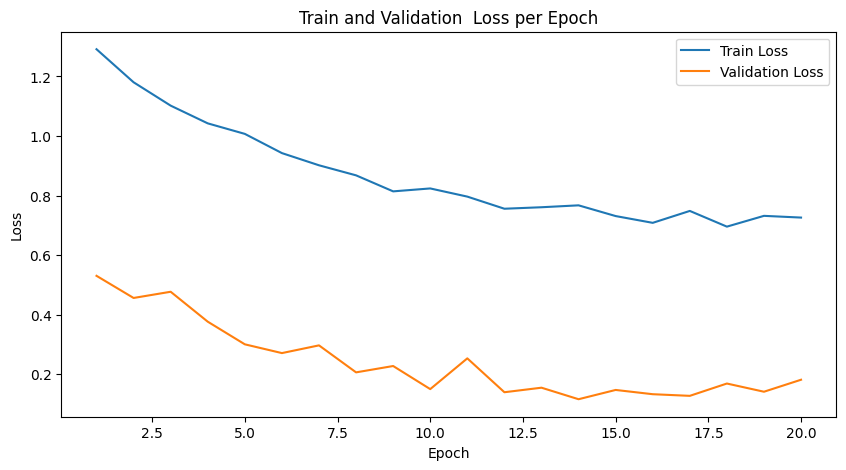

Training Complete. Model saved to /home/wouterf/Documents/DS&AI Courses/DL/assignment-1/garden_model_t3.pth


In [24]:
print(f"Using device: {device}")

# wrap original datasets for Trainer
train_data_wrapper = JointDatasetWrapper(train_data_both)
test_data_wrapper  = JointDatasetWrapper(test_data_both)

# setup samplers and dataloaders
# define train dataloader. Note balanced batch sampler uses item labels only, not family
train_sampler_t3 = BalancedBatchSampler(train_data_wrapper.targets_item, n_classes=10, n_samples=20)
train_loader_t3  = torch.utils.data.DataLoader(
    train_data_wrapper, batch_sampler=train_sampler_t3,
    num_workers=4 if platform.node()=="WFcachyOS" else 0, pin_memory=True
)

# define validation sampler and loader
val_sampler_t3 = BalancedBatchSampler(test_data_wrapper.targets_item, n_classes=10, n_samples=20)
val_loader_t3  = torch.utils.data.DataLoader(
    test_data_wrapper, batch_sampler=val_sampler_t3,
    num_workers=4 if platform.node()=="WFcachyOS" else 0, pin_memory=True
)

# init adapted criterion
criterion_joint_train = JointTripletLoss(margin=1, is_validation=False)
criterion_joint_val   = JointTripletLoss(margin=1, is_validation=True)

# init model and optimizer
garden_model_t3 = EmbeddingNet(embedding_dim=128).to(device)
optimizer_t3= torch.optim.Adam(garden_model_t3.parameters(), lr=1e-3, weight_decay=1e-5)

base_path = get_base_path()
model_save_path_t3 = os.path.join(base_path, "garden_model_t3.pth")

if os.path.exists(model_save_path_t3):
    print("Found existing Task 3 model weights. Loading...")
    checkpoint_t3 = torch.load(model_save_path_t3, map_location=device, weights_only=False)
    garden_model_t3.load_state_dict(checkpoint_t3["model_state_dict"])
    garden_model_t3.eval()
    print("Model loaded successfully!")
    plot_loss_history(checkpoint_t3['train_losses'], checkpoint_t3['validation_losses'])
else:
    print("No saved weights found. Starting Training...")
    trainer_t3 = Trainer(
        model=garden_model_t3, 
        device=device,
        criterion=criterion_joint_train, 
        optimizer=optimizer_t3,
        train_DataLoader=train_loader_t3,
        validation_DataLoader=val_loader_t3,
        n_epochs=20,
        criterion_validation=criterion_joint_val
    )

    train_losses_t3, val_losses_t3 = trainer_t3.run_trainer()

    # create checkpoint
    checkpoint = {
        'model_state_dict': garden_model_t3.state_dict(),
        'train_losses': train_losses_t3,
        'validation_losses': val_losses_t3
    }
    torch.save(checkpoint, model_save_path_t3)
    print(f"Training Complete. Model saved to {model_save_path_t3}")

Evaluate Performance

In [26]:
# mapping item to family predictions
item_idx_to_family_idx = {}
for fam_lbl, item_lbl in zip(train_data.targets_family, train_data.targets_item):
    item_idx_to_family_idx[item_lbl] = fam_lbl

def item_preds_to_family_preds(item_preds):
    return np.array([item_idx_to_family_idx[p] for p in item_preds])

# extract embeddings
train_embs, train_item_lbls = extract_embeddings(train_data, garden_model_t3)
test_embs, test_item_lbls = extract_embeddings(test_data, garden_model_t3)
train_family_lbls = np.array(train_data.targets_family)
test_family_lbls = np.array(test_data.targets_family)

support_all_embs, support_all_item_lbls = extract_embeddings(support_all_data, garden_model_t3)
test_new_embs, test_new_item_lbls = extract_embeddings(test_new_data, garden_model_t3)

# scenario 1
acc1_t3, preds1_t3 = retrieval_classification_accuracy(
    train_embs, train_item_lbls, test_embs, test_item_lbls, k=5)
print(f"Scenario 1 - Item accuracy (seen): {acc1_t3:.4f}")

# scenario 2
preds2_family_t3 = item_preds_to_family_preds(preds1_t3)
acc2_t3 = np.mean(preds2_family_t3 == test_family_lbls)
print(f"Scenario 2 - Family accuracy (seen): {acc2_t3:.4f}")

# scenario 3
acc3_t3, preds3_t3 = retrieval_classification_accuracy(
    support_all_embs, support_all_item_lbls, test_new_embs, test_new_item_lbls, k=5)
print(f"Scenario 3 - Item accuracy (new items): {acc3_t3:.4f}")

# scenario 4
support_all_fam_embs, support_all_fam_lbls = extract_embeddings(support_all_data_family, garden_model_t3)
test_new_fam_embs, test_new_fam_lbls = extract_embeddings(test_new_data_family, garden_model_t3)
acc4_t3, preds4_t3 = retrieval_classification_accuracy(
    support_all_fam_embs, support_all_fam_lbls, test_new_fam_embs, test_new_fam_lbls, k=5)
print(f"Scenario 4 - Family accuracy (new families): {acc4_t3:.4f}")

Extracting embeddings:   0%|          | 0/217 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/109 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/248 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/16 [00:00<?, ?it/s]

Scenario 1 - Item accuracy (seen): 0.9925
Scenario 2 - Family accuracy (seen): 0.9999
Scenario 3 - Item accuracy (new items): 0.9944


Extracting embeddings:   0%|          | 0/250 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/17 [00:00<?, ?it/s]

Scenario 4 - Family accuracy (new families): 0.9976


Generate Confusion Matrix to Compare

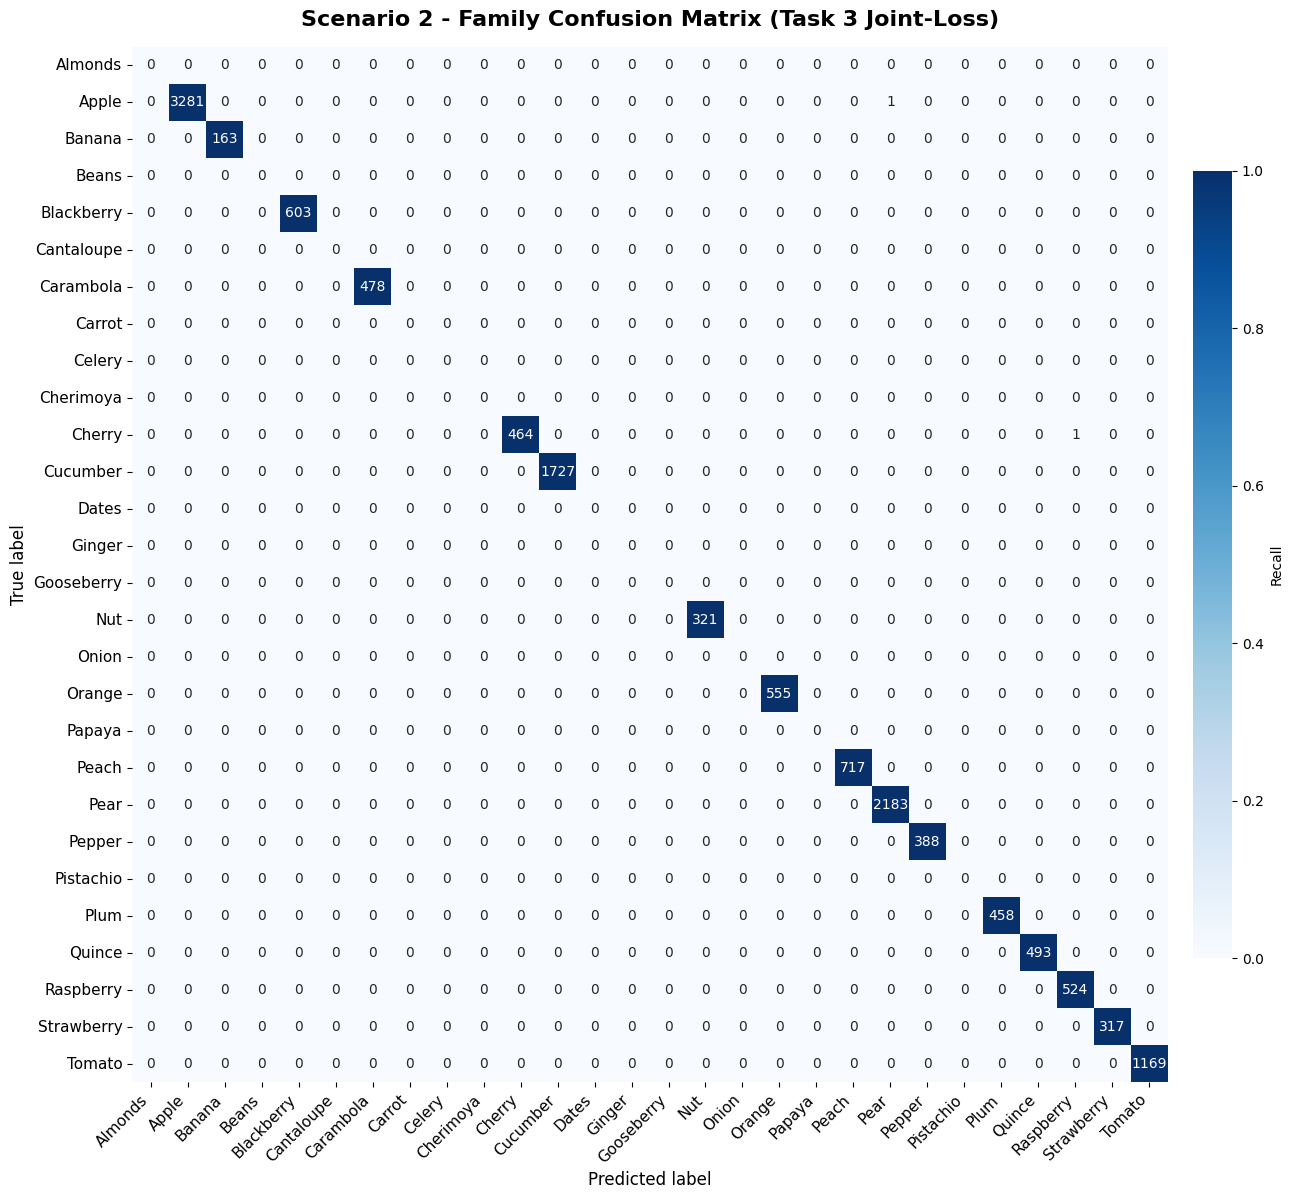

In [27]:
# generate matrix using the new Task 3 predictions (preds2_family_t3)
cm_raw_t3 = confusion_matrix(
    test_family_lbls, preds2_family_t3, 
    labels=sorted(family_name_lookup)
)
cm_norm_t3 = confusion_matrix(
    test_family_lbls, preds2_family_t3, 
    labels=sorted(family_name_lookup), 
    normalize='true' 
)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm_t3, annot=cm_raw_t3, fmt="d", cmap="Blues",
            xticklabels=ordered_family_names, yticklabels=ordered_family_names,
            square=True, annot_kws={"size": 10},
            cbar_kws={'shrink': 0.75, 'pad': 0.02, 'label': 'Recall'})

plt.title("Scenario 2 - Family Confusion Matrix (Task 3 Joint-Loss)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

## Task 4

#### 4.1 ...?

In [ ]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).
    
    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        BlackoutPixels(fraction=fraction),
        transforms.Normalize(mean=(0.6123, 0.5190, 0.4066), std=(0.2739, 0.3120, 0.3521))
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
...

#### 4.2 AutoEncoder

Defining a Simple AutoEncoder Class

In [ ]:
class SimpleAutoEncoder(nn.Module):

    def __init__(self, embedding_dim=128):
        super().__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8,kernel_size=3,stride=1,padding=1), # 3 x 28x28 -> 8 x 28x28 (bc padding)
            # -> padding=1 to keep decoder happy
            nn.ReLU(),
            nn.MaxPool2d(2,stride=2), # 8 x 128x128 -> 8 x 64x64
            nn.Conv2d(in_channels=8,out_channels=4,kernel_size=3,stride=1,padding=1), # 8 x 64x64 -> 4 x 64x64 (bc padding)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2), # 4 x 64x64 -> 4 x 32x32
            nn.Flatten(), # (batch, 4, 32, 32) -> (batch, 4,096)
            nn.Linear(4096,embedding_dim) # 32*32*4 -> embedding_dim
        )
        # decoder 
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim,4096), # embedding_dim -> 4096
            nn.Unflatten(1,(4,32,32)), # (batch,4096) -> (batch,4,32,32)
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=4,out_channels=8,kernel_size=3,stride=2,padding=1,output_padding=1), # 4 x 32x32 -> 8 x 63x63 (bc padding=1) -> 8 x 64x64 (bc output_padding)
            # -> padding=1 shrinks the output size on both sides (-2)
            # -> output_padding=1 adds 1
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=8,out_channels=3,kernel_size=3,stride=2,padding=1,output_padding=1), # 8 x 64x64 -> 1 x 127x127 (bc padding=1) -> 1 x 128x128 (bc output_padding)
            # data not bounded so not using any activation function
        )

    def forward(self, x):
        embedding = self.encoder(x)
        reconstruction = self.decoder(embedding)
        return reconstruction, embedding

Defining Training Loop

In [ ]:
def train_autoencoder(model, device, save_path, n_epochs, criterion, optimizer, data_loader):
    print("Starting Training")

    train_losses_per_epoch = []
    model = model.to(device)

    # train the model
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        
        train_bar = tqdm(
            enumerate(data_loader),
            total=len(data_loader),
            desc=f"Training epoch {epoch + 1}/{n_epochs}",
            leave=True,
            dynamic_ncols=True
        )

        for batch_idx,batch in train_bar:
            img_batch,_ = batch
            optimizer.zero_grad()
            img_batch = img_batch.to(device)

            # forward
            reconstructions, _ = model(img_batch)

            # loss
            loss = criterion(reconstructions,img_batch)

            # backward
            loss.backward()
            optimizer.step()

            total_loss+=loss.item()

        # compute print and store avg loss for this epoch
        avg_loss = total_loss/len(data_loader)
        print(f"Epoch {epoch+1}: Average loss: {avg_loss}")
        train_losses_per_epoch.append(avg_loss)

    model.eval()
    

    # create checkpoint: store model weights and losses
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'train_losses': train_losses_per_epoch
    }
    torch.save(checkpoint, save_path)
    print("Autoencoder training complete and weights saved!")

    return train_losses_per_epoch

Training the Simple AutoEncoder

In [ ]:
# define dataloader
train_dl = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0, pin_memory=True) # num_workers=4 for Linux

# vars
EMBEDDING_DIM = 128
n_epochs = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
simple_ae = SimpleAutoEncoder(embedding_dim=EMBEDDING_DIM).to(device)

criterion = F.mse_loss
optimizer = torch.optim.Adam(simple_ae.parameters(), lr=0.001)

base_path = get_base_path()
simple_ae_save_path = os.path.join(base_path,"simpleautoencoder_weights.pth")

if os.path.exists(simple_ae_save_path):
    print("Found existing model weights. Loading...")
    # load dictionary
    checkpoint = torch.load(simple_ae_save_path, map_location=device, weights_only=False)
    
    # load weights and set model to eval mode
    simple_ae.load_state_dict(checkpoint["model_state_dict"])
    simple_ae.eval()
    print("Model loaded successfully!")

    train_losses = checkpoint.get("train_losses", [])
else:
    print("No saved weights found. Starting training...")

    # training
    train_losses = train_autoencoder(
        model=simple_ae,
        device=device,
        save_path=simple_ae_save_path,
        n_epochs=n_epochs,
        criterion=criterion,
        optimizer=optimizer,
        data_loader=train_dl
    )
    print(f"Training Complete. Model saved to {simple_ae_save_path}")
    # 20 min 27.7s on rtx 3090 x ryzen 5 7600x
plot_loss_history(train_losses,None)

Defining Larger AutoEncoder Class

In [ ]:
class AutoEncoder(nn.Module):

    def __init__(self, embedding_dim=128):
        super().__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16,kernel_size=3,stride=1,padding=1), # 3 x 28x28 -> 16 x 28x28 (bc padding)
            # -> padding=1 to keep decoder happy
            nn.ReLU(),
            nn.MaxPool2d(2,stride=2), # 16 x 128x128 -> 16 x 64x64
            nn.Conv2d(in_channels=16,out_channels=8,kernel_size=3,stride=1,padding=1), # 16 x 64x64 -> 8 x 64x64 (bc padding)
            nn.ReLU(),
            nn.MaxPool2d(2,stride=2), # 8 x 64x64 -> 8 x 32x32
            nn.Flatten(), # (batch, 8, 32, 32) -> (batch, 8192)
            nn.Linear(8192,embedding_dim) # 32*32*8 -> embedding_dim
        )
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim,8192), # embedding_dim -> 8192
            nn.Unflatten(1,(8,32,32)), # (batch,8192) -> (batch,8,32,32)
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=8,out_channels=16,kernel_size=3,stride=2,padding=1,output_padding=1), # 8 x 32x32 -> 16 x 63x63 (bc padding=1) -> 16 x 64x64 (bc output_padding)
            # -> padding=1 shrinks the output size on both sides (-2)
            # -> output_padding=1 adds 1
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16,out_channels=3,kernel_size=3,stride=2,padding=1,output_padding=1), # 16 x 64x64 -> 3 x 127x127 (bc padding=1) -> 3 x 128x128 (bc output_padding)
            # data not bounded so not using any activation function
            # nn.Tanh() / nn.Sigmoid()
        )

    def forward(self, x):
        embedding = self.encoder(x)
        reconstruction = self.decoder(embedding)
        return reconstruction, embedding

Training Larger AutoEncoder

In [ ]:
# define dataloader
train_dl = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0, pin_memory=True) # num_workers=4 for Linux

# vars
EMBEDDING_DIM = 128
n_epochs = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae = AutoEncoder(embedding_dim=EMBEDDING_DIM).to(device)

criterion = F.mse_loss
optimizer = torch.optim.Adam(ae.parameters(), lr=0.001)

base_path = get_base_path()
ae_save_path = os.path.join(base_path,"autoencoder_weights.pth")

if os.path.exists(ae_save_path):
    print("Found existing model weights. Loading...")
    # load dictionary
    checkpoint = torch.load(ae_save_path, map_location=device, weights_only=False)
    
    # load weights and set model to eval mode
    ae.load_state_dict(checkpoint["model_state_dict"])
    ae.eval()
    print("Model loaded successfully!")

    train_losses = checkpoint.get("train_losses", [])
else:
    print("No saved weights found. Starting training...")

    # training
    train_losses = train_autoencoder(
        model=ae,
        device=device,
        save_path=ae_save_path,
        n_epochs=n_epochs,
        criterion=criterion,
        optimizer=optimizer,
        data_loader=train_dl
    )
    print(f"Training Complete. Model saved to {ae_save_path}")
    # 21min 6.5s
plot_loss_history(train_losses,None)

Test 1: Finding The Error Threshold When Tolerating 10% Of Normal Test Samples Being Wrongly
Flagged As Anomalies

In [ ]:
test_dl = DataLoader(
    test_data,
    batch_size=128,
    shuffle=False,
    num_workers=0 if platform.system()=="Windows" else 4,
    pin_memory=1
)

simple_ae_mse_scores = []
ae_mse_scores = []

criterion = F.mse_loss

print("Calculating normal test set reconstructions...")
simple_ae.eval()
ae.eval()
with torch.no_grad():
    for img_batch,_ in tqdm(test_dl,desc="Evaluating normal test data"):
        img_batch = img_batch.to(device)

        recons_simple_ae,_ = simple_ae(img_batch)
        recons_ae,_ = ae(img_batch)
        
        # get loss per pixel of each image
        loss_simple_ae_per_pixel = criterion(recons_simple_ae,img_batch,reduction='none')
        loss_ae_per_pixel = criterion(recons_ae,img_batch,reduction='none')

        # get average across the three channels to get per-image MSE
        # loss_simple_ae_per_image = loss_simple_ae_per_pixel.mean(dim=(1,2,3)) #[batch,3,128,128] -> [batch]
        # loss_ae_per_image = loss_ae_per_pixel.mean(dim=(1,2,3))
        
        # instead of mean, get maximum error across all pixels
        loss_simple_ae_per_image = loss_simple_ae_per_pixel.amax(dim=(1,2,3)) #[batch,3,128,128] -> [batch]
        loss_ae_per_image = loss_ae_per_pixel.amax(dim=(1,2,3))

        # move to cpu and append
        simple_ae_mse_scores.extend(loss_simple_ae_per_image.cpu().numpy())
        ae_mse_scores.extend(loss_ae_per_image.cpu().numpy())

# compute 90th percentile threshold (10% FPR (False Positive Rate))
threshold_simple_ae = np.percentile(simple_ae_mse_scores, 90)
threshold_ae = np.percentile(ae_mse_scores, 90)

print(f"Simple AutoEncoder Threshold: {threshold_simple_ae:.4f}")
print(f"Complex AutoEncoder Threshold: {threshold_ae:.4f}")

Test 2: Anomoly Detection Percentage For Test Data With 1%, 5%, And 10% Black Pixels

In [ ]:
for fraction in [0.01, 0.05, 0.1]:

    # get test dataset and create dataloader
    anomaly_data = get_anomaly_dataset(fraction)
    anomaly_dl = DataLoader(
        anomaly_data,
        batch_size=128,
        shuffle=False,
        num_workers=0 if platform.system()=="Windows" else 4,
        pin_memory=1
    )

    simple_ae_anomalies_detected = 0
    ae_anomalies_detected = 0
    total_images = 0

    with torch.no_grad():
        for img_batch,_ in tqdm(anomaly_dl,desc=f"Evaluating Anomaly Data with {int(fraction*100)}% Randomly Blacked Out Pixels"):
            img_batch = img_batch.to(device)

            recons_simple_ae,_ = simple_ae(img_batch)
            recons_ae,_ = ae(img_batch)
            
            # get average loss of each image
            # loss_simple_ae = criterion(recons_simple_ae,img_batch,reduction='none').mean(dim=(1,2,3))
            # loss_ae = criterion(recons_ae,img_batch,reduction='none').mean(dim=(1,2,3))

            # instead of average, get max loss
            loss_simple_ae = criterion(recons_simple_ae,img_batch,reduction='none').amax(dim=(1,2,3))
            loss_ae = criterion(recons_ae,img_batch,reduction='none').amax(dim=(1,2,3))
            
            # count anomalies
            simple_ae_anomalies_detected += (loss_simple_ae > threshold_simple_ae).sum().item()
            ae_anomalies_detected += (loss_ae > threshold_ae).sum().item()

            total_images += img_batch.size(0)

    # compute percentages
    simple_ae_rate = (simple_ae_anomalies_detected / total_images) * 100
    ae_rate = (ae_anomalies_detected / total_images) * 100
    
    # print results
    print(f"Results for {int(fraction*100)}% black pixels:")
    print(f" > Simple AE Detection Rate : {simple_ae_rate:.2f}%")
    print(f" > AE Detection Rate        : {ae_rate:.2f}%")